(-10.0, 10.0)

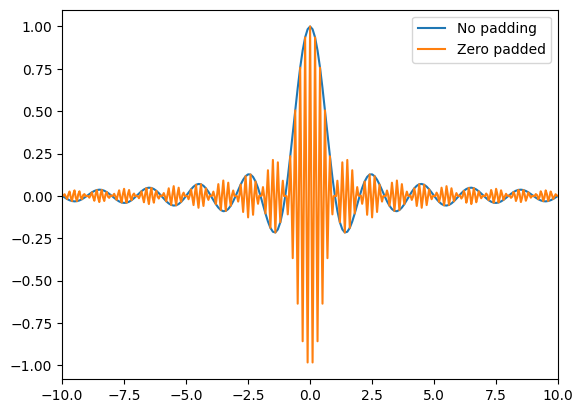

In [1]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.01
t = np.arange(-5,5,dt)
x = np.where(np.abs(t) < 1/2,1,0)

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))*dt

x_padded = np.concatenate([x, np.zeros(1000)])
X_padded = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x_padded)))*dt


f = np.fft.fftshift(np.fft.fftfreq(len(t),dt))
f_padded = np.fft.fftshift(np.fft.fftfreq(len(X_padded),dt))
plt.plot(f, np.real(X), label='No padding')
plt.plot(f_padded, np.real(X_padded), label='Zero padded')
plt.legend()
plt.xlim(-10,10)

### Leakage Showcase

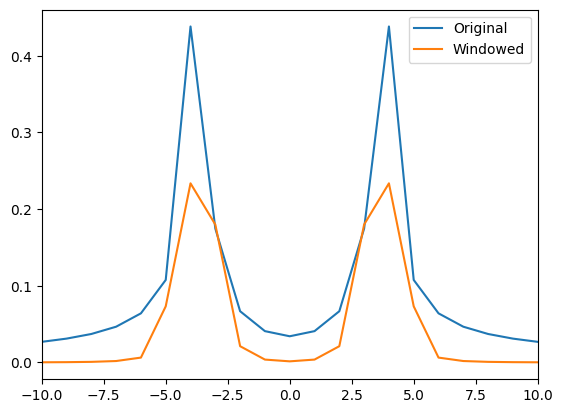

In [4]:
dt = 0.01
t = np.arange(0, 1, dt)
x = np.cos(2*np.pi*3.7*t)

window = 0.5 * (1 - np.cos(2*np.pi*t/t[-1]))
x_windowed = x * window

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x))) * dt
X_windowed = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x_windowed))) * dt
f = np.fft.fftshift(np.fft.fftfreq(len(t), dt))

plt.plot(f, np.abs(X), label='Original')
plt.plot(f, np.abs(X_windowed), label='Windowed')
plt.xlim(-10, 10)
plt.legend()
plt.show()

/tmp/ipykernel_23072/780942512.py:41: RuntimeWarning: divide by zero encountered in log10
  W_db = 20 * np.log10(np.abs(W) / np.max(np.abs(W)))  # normalized dB
/tmp/ipykernel_23072/780942512.py:49: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[3, i].set_xscale('log')


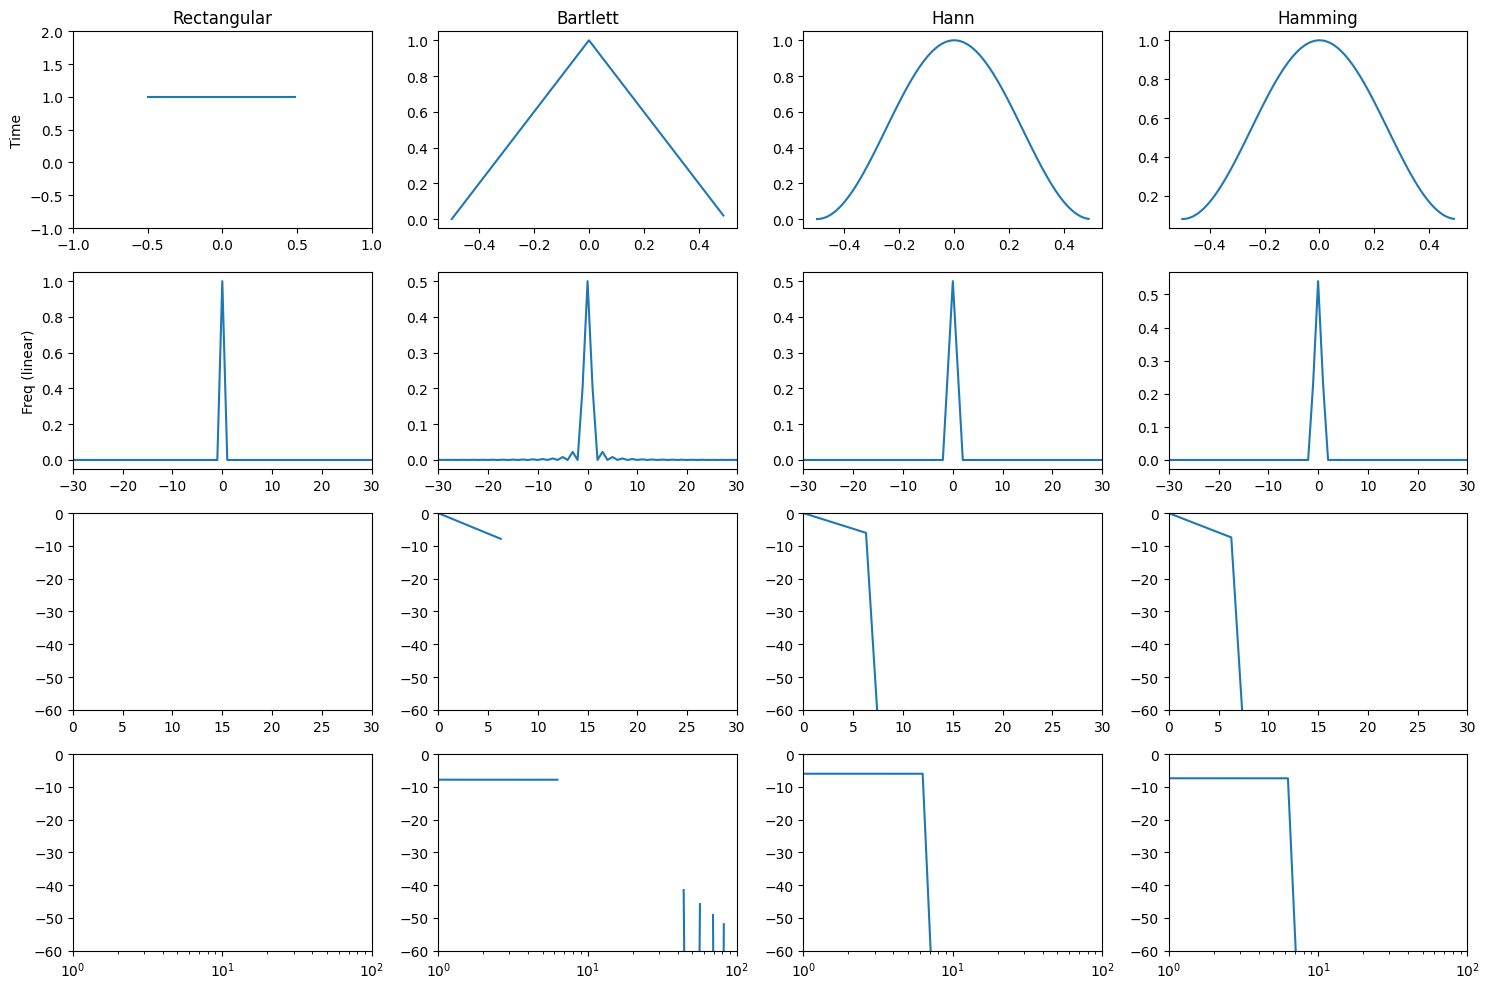

In [24]:
T0 = 1
dt = 0.01
t = np.arange(-T0/2, T0/2, dt)

rect = np.where( np.abs(t) <= T0/2, 1, 0)
bart = 1-2*np.abs(t)/T0
hann = 1/2*(1+np.cos(2*np.pi * t/ T0))
hamm = 0.54 + 0.46*np.cos(np.pi * 2 * t / T0)


def arrayFFT(signal, dt):
    return np.fft.fftshift(np.fft.fft(np.fft.ifftshift(signal))) * dt

Rect = arrayFFT(rect,dt)
Bart = arrayFFT(bart,dt)
Hann = arrayFFT(hann,dt)
Hamm = arrayFFT(hamm,dt)

f = np.fft.fftshift(np.fft.fftfreq(len(t),dt))
fig, ax = plt.subplots(4, 4, figsize=(15, 10))

windows = [rect, bart, hann, hamm]
names = ['Rectangular', 'Bartlett', 'Hann', 'Hamming']
FFTs = [Rect, Bart, Hann, Hamm]

for i, (w, name, W) in enumerate(zip(windows, names, FFTs)):
    # Row 1 - time domain
    ax[0, i].plot(t, w)
    ax[0, i].set_title(name)
    if i == 0: 
        ax[0, i].set_ylabel('Time')
        ax[0, i].set_ylim(-1,2)
        ax[0, i].set_xlim(-1,1)

    # Row 2 - frequency linear
    ax[1, i].plot(f, np.abs(W))
    ax[1, i].set_xlim(-30, 30)
    if i == 0: ax[1, i].set_ylabel('Freq (linear)')

    # Row 3 - dB scale, linear x
    W_db = 20 * np.log10(np.abs(W) / np.max(np.abs(W)))  # normalized dB
    ax[2, i].plot(2*np.pi*f[f>=0], W_db[f>=0])
    ax[2, i].set_ylim(-60, 0)
    ax[2, i].set_xlim(0, 30)


    # Row 4 - dB scale, log x
    ax[3, i].plot(2*np.pi*f[f>=0], W_db[f>=0])
    ax[3, i].set_xscale('log')
    ax[3, i].set_ylim(-60, 0)
    ax[3, i].set_xlim(1, 100)


plt.tight_layout()
plt.show()